# Vector Transformation Pilot

Tests whether difference vectors between ModernBERT's predicted and observed token embeddings
at high-surprisal positions cluster into interpretable linguistic error categories that vary by L2 proficiency.

In [1]:
# Cell 1 — Setup and Model Loading

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import spacy
from transformers import AutoTokenizer, AutoModelForMaskedLM

sys.path.insert(0, str(Path(".").resolve().parent))
from features.predictability import Predictor, get_centered_window
from util.paths import DATA_DIR, FIG_DIR

# Load ModernBERT
model_name = "answerdotai/ModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForMaskedLM.from_pretrained(model_name)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()
print(f"Model on {device}")

# Extract tied embedding matrix
W_E = model.get_input_embeddings().weight.detach()
print(f"Embedding matrix shape: {W_E.shape}")

# Verify tied embeddings (model-agnostic method)
input_ptr = model.get_input_embeddings().weight.data_ptr()
output_ptr = model.get_output_embeddings().weight.data_ptr()
assert input_ptr == output_ptr, "Embeddings are NOT tied!"
print("Tied embeddings verified ✓")

# Load ELLIPSE data
essays = pd.read_csv(DATA_DIR / "ELLIPSE_Final_github.csv")
print(f"Loaded {len(essays)} essays")

# Load spaCy
nlp = spacy.load("en_core_web_lg")
print("spaCy loaded")

Model on cuda
Embedding matrix shape: torch.Size([50368, 768])
Tied embeddings verified ✓
Loaded 6482 essays
spaCy loaded


In [2]:
# Cell 2 — Define compute_transformation_vectors()

crossloss = torch.nn.CrossEntropyLoss(reduction="none")


def compute_transformation_vectors(
    doc,
    essay_id,
    overall_score,
    prof_tertile,
    predictor,
    W_E,
    surprisal_threshold,
    window_size=64,
    top_k=50,
    target_spacy_indices=None,
):
    """
    Process one document, computing transformation vectors at positions
    exceeding the surprisal threshold.

    Adapts the batched masking logic from Predictor._process_masked but
    also computes delta = e_pred - e_obs for high-surprisal tokens.

    If target_spacy_indices is provided, only those token positions are
    processed (pre-filtered from per-token surprisal data). This avoids
    running the model on every token in the essay. The surprisal_threshold
    is still checked as a safety net.

    Returns a list of dicts, one per qualifying token.
    """
    token_map, trf_tok_ids = predictor.get_token_alignment(doc)
    if not token_map:
        return []

    seq_len = len(trf_tok_ids)
    effective_window = min(window_size, seq_len)
    mask_id = predictor.mask_id

    # Build masked sequences only for target positions
    sequences_to_process = []
    spacy_indices = []
    mask_positions_list = []
    tok_indices_list = []

    for spacy_idx, (subword_start, subword_end) in token_map.items():
        # Skip tokens not in pre-filtered set (if provided)
        if target_spacy_indices is not None and spacy_idx not in target_spacy_indices:
            continue

        win_start, win_end = get_centered_window(seq_len, subword_start, effective_window)
        window_len = win_end - win_start
        window_ids = trf_tok_ids[win_start:win_end].copy()

        tok_start_in_window = max(0, subword_start - win_start)
        tok_end_in_window = min(window_len, subword_end - win_start)
        if tok_end_in_window <= tok_start_in_window:
            continue

        tok_indices = np.arange(tok_start_in_window, tok_end_in_window)
        window_ids[tok_indices] = mask_id

        sequences_to_process.append(window_ids)
        spacy_indices.append(spacy_idx)
        mask_positions_list.append(tok_indices + 1)  # +1 for [CLS]
        actual_start = win_start + tok_start_in_window
        actual_end = win_start + tok_end_in_window
        tok_indices_list.append((actual_start, actual_end))

    if not sequences_to_process:
        return []

    results = []
    batch_size = predictor.batch_size
    cls_id = tokenizer.cls_token_id
    sep_id = tokenizer.sep_token_id
    pad_id = tokenizer.pad_token_id or 0

    for i in range(0, len(sequences_to_process), batch_size):
        batch_seqs = sequences_to_process[i : i + batch_size]
        batch_spacy = spacy_indices[i : i + batch_size]
        batch_mask_pos = mask_positions_list[i : i + batch_size]
        batch_tok_inds = tok_indices_list[i : i + batch_size]

        full_seqs = [[cls_id] + seq.tolist() + [sep_id] for seq in batch_seqs]
        max_len = max(len(s) for s in full_seqs)

        padded_seqs = []
        attention_masks = []
        for seq in full_seqs:
            pad_len = max_len - len(seq)
            padded_seqs.append(seq + [pad_id] * pad_len)
            attention_masks.append([1] * len(seq) + [0] * pad_len)

        input_ids = torch.tensor(padded_seqs, device=device)
        attention_mask = torch.tensor(attention_masks, device=device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

        for j, (spacy_idx, mask_pos, (sub_start, sub_end)) in enumerate(
            zip(batch_spacy, batch_mask_pos, batch_tok_inds)
        ):
            actual_ids = trf_tok_ids[sub_start:sub_end]
            if len(actual_ids) == 0:
                continue

            # Compute mean loss across subwords
            losses = []
            for pos, actual_id in zip(mask_pos, actual_ids):
                if pos >= logits.shape[1]:
                    continue
                pred_logits = logits[j, pos]
                target = torch.tensor([int(actual_id)], device=device)
                loss = crossloss(pred_logits.unsqueeze(0), target).item()
                losses.append(loss)

            if not losses:
                continue
            mean_loss = np.mean(losses)

            # Safety net: skip if below threshold (redundant when
            # target_spacy_indices is pre-filtered, but keeps behavior
            # correct if called without pre-filtering)
            if mean_loss < surprisal_threshold:
                continue

            # Compute transformation vector using FIRST SUBWORD only.
            # For multi-subword tokens (e.g., "unforgettable" -> ["un",
            # "##forget", "##table"]), only the first subword's predicted
            # distribution and embedding are used. The first subword typically
            # carries the most semantic content. Averaging deltas across
            # subword positions would mix independently predicted masks at
            # different sequence positions, which is not clearly meaningful.
            pos = mask_pos[0]
            if pos >= logits.shape[1]:
                continue
            pred_logits = logits[j, pos]
            probs = torch.softmax(pred_logits, dim=-1)
            actual_id = int(actual_ids[0])

            top_probs, top_idx = torch.topk(probs, k=top_k)
            top_probs = top_probs / top_probs.sum()  # renormalize
            e_pred = (top_probs.unsqueeze(1) * W_E[top_idx]).sum(dim=0)
            e_obs = W_E[actual_id]
            delta = (e_pred - e_obs).cpu().numpy()

            # Top-3 predicted tokens for interpretability
            top3_probs, top3_idx = torch.topk(probs, k=3)
            top3_tokens = [tokenizer.decode([tid]) for tid in top3_idx.tolist()]
            top3_probs_list = top3_probs.tolist()

            # Context
            token = doc[spacy_idx]
            left_start = max(0, spacy_idx - 10)
            right_end = min(len(doc), spacy_idx + 11)
            left_context = doc[left_start:spacy_idx].text
            right_context = doc[spacy_idx + 1 : right_end].text

            results.append({
                "essay_id": essay_id,
                "spacy_idx": spacy_idx,
                "token_text": token.text,
                "surprisal": mean_loss,
                "delta": delta,
                "pos_tag": token.pos_,
                "dep_rel": token.dep_,
                "left_context": left_context,
                "right_context": right_context,
                "overall_score": overall_score,
                "prof_tertile": prof_tertile,
                "top3_predicted": top3_tokens,
                "top3_probs": top3_probs_list,
            })

    return results

Loaded 3010382 token records
Proficiency cutoff (top tertile): Overall >= 3.50
Surprisal threshold (90th pctl of top tertile): 4.167 nats


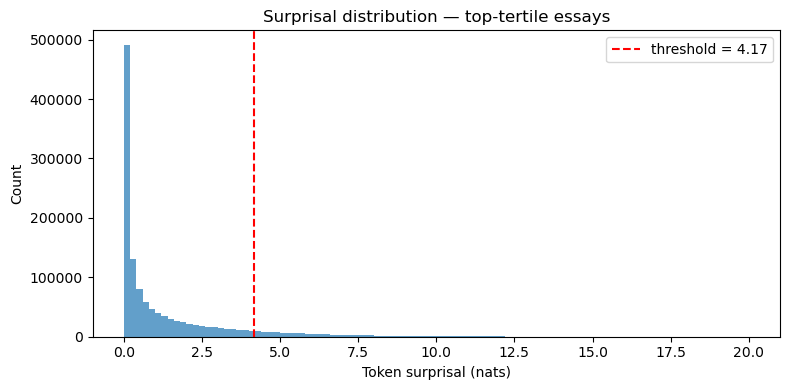

In [3]:
# Cell 3 — Establish Surprisal Threshold (from saved per-token data)

token_df = pd.read_parquet(DATA_DIR / "ELLIPSE_token_predictability.parquet")
print(f"Loaded {len(token_df)} token records")

# Merge to get proficiency scores
token_df = token_df.merge(
    essays[["text_id_kaggle", "Overall"]], on="text_id_kaggle"
)

# Top-tertile essays as reference for "native-like" surprisal
# Compute cutoff from essay-level data to avoid biasing by essay length
cutoff = essays["Overall"].quantile(0.667)
reference = token_df[token_df["Overall"] >= cutoff]
threshold = reference["mean_loss"].quantile(0.90)
print(f"Proficiency cutoff (top tertile): Overall >= {cutoff:.2f}")
print(f"Surprisal threshold (90th pctl of top tertile): {threshold:.3f} nats")

# Sanity: plot distribution
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(reference["mean_loss"].clip(upper=20), bins=100, alpha=0.7, edgecolor="none")
ax.axvline(threshold, color="red", linestyle="--", label=f"threshold = {threshold:.2f}")
ax.set_xlabel("Token surprisal (nats)")
ax.set_ylabel("Count")
ax.set_title("Surprisal distribution — top-tertile essays")
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
# Cell 4 — Select Stratified Sample

# Compute proficiency tertiles
essays["prof_tertile"] = pd.qcut(essays["Overall"], q=3, labels=["low", "mid", "high"])
print(essays["prof_tertile"].value_counts())

# Stratified sample: ~333 per tertile
sample = essays.groupby("prof_tertile", observed=True).apply(
    lambda g: g.sample(n=min(333, len(g)), random_state=42),
    include_groups=False,
).reset_index(level=0)
print(f"\nSampled {len(sample)} essays:")
print(sample["prof_tertile"].value_counts())

prof_tertile
low     4074
mid     1302
high    1106
Name: count, dtype: int64

Sampled 999 essays:
prof_tertile
low     333
mid     333
high    333
Name: count, dtype: int64


In [5]:
# Cell 5 — Extract Transformation Vectors

from tqdm.auto import tqdm

# Initialize predictor (for get_token_alignment)
predictor = Predictor(
    tokenizer=tokenizer,
    model=model,
    model_type="masked",
    batch_size=32,
    device=device,
)

# Pre-filter: identify high-surprisal token positions from pipeline output
# so we only run the model on positions that need delta vectors
sample_ids = set(sample["text_id_kaggle"])
high_surp_tokens = token_df[
    (token_df["text_id_kaggle"].isin(sample_ids))
    & (token_df["mean_loss"] >= threshold)
]
high_surp_lookup = (
    high_surp_tokens.groupby("text_id_kaggle")["spacy_idx"].apply(set).to_dict()
)
print(f"Pre-filtered {len(high_surp_tokens)} high-surprisal tokens "
      f"across {len(high_surp_lookup)} essays")

all_records = []
errors = []

for idx, row in tqdm(sample.iterrows(), total=len(sample), desc="Extracting deltas"):
    essay_id = row["text_id_kaggle"]
    target_indices = high_surp_lookup.get(essay_id)
    if not target_indices:
        continue  # No high-surprisal tokens in this essay

    text = row["full_text"]
    if pd.isna(text) or text.strip() == "":
        continue
    try:
        doc = nlp(text)
        records = compute_transformation_vectors(
            doc=doc,
            essay_id=essay_id,
            overall_score=row["Overall"],
            prof_tertile=row["prof_tertile"],
            predictor=predictor,
            W_E=W_E,
            surprisal_threshold=threshold,
            target_spacy_indices=target_indices,
        )
        all_records.extend(records)
    except Exception as e:
        errors.append((essay_id, str(e)))

print(f"\nExtracted {len(all_records)} transformation vectors")
if errors:
    print(f"Errors on {len(errors)} essays")

# Separate deltas from metadata
deltas = np.array([r["delta"] for r in all_records])
metadata = pd.DataFrame([{k: v for k, v in r.items() if k != "delta"} for r in all_records])
print(f"Delta matrix shape: {deltas.shape}")

# Checkpoint
np.save(DATA_DIR / "pilot_deltas.npy", deltas)
metadata.to_parquet(DATA_DIR / "pilot_metadata.parquet", index=False)
print("Saved pilot_deltas.npy and pilot_metadata.parquet")

Pre-filtered 56021 high-surprisal tokens across 999 essays


Extracting deltas:   0%|          | 0/999 [00:00<?, ?it/s]

/home/jovyan/conda_envs/hf/lib/python3.11/site-packages/torch/_inductor/compile_fx.py:194: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(



Extracted 55998 transformation vectors
Delta matrix shape: (55998, 768)
Saved pilot_deltas.npy and pilot_metadata.parquet
